In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
rd=pd.read_csv('c:/Users/heman/Downloads/archive/ncr_ride_bookings.csv')
#print(rd.to_string())
#print(rd.columns)
#print(rd.info())
#print(rd.describe())
#rd.isnull().sum()
#rd.head(10)
if 'Date' in rd.columns:
    rd['Date']=pd.to_datetime(rd['Date'])
if 'Avg VTAT' in rd.columns:
    rd['Avg VTAT']=rd['Avg VTAT'].fillna(0)
if 'Avg CTAT' in rd.columns:
    rd['Avg CTAT']=rd['Avg CTAT'].fillna(0)
if 'Cancelled Rides by Customer' in rd.columns:
    rd['Cancelled Rides by Customer']=rd['Cancelled Rides by Customer'].fillna(0)
if 'Cancelled Rides by Driver' in rd.columns:
    rd['Cancelled Rides by Driver']=rd['Cancelled Rides by Driver'].fillna(0)
if 'Incomplete Rides' in rd.columns:
    rd['Incomplete Rides']=rd['Incomplete Rides'].fillna(0)
if 'Booking Value' in rd.columns:
    rd['Booking Value']=rd['Booking Value'].fillna(0)
if 'Ride Distance' in rd.columns:
    rd['Ride Distance']=rd['Ride Distance'].fillna(0)
if 'Driver Ratings' in rd.columns:
    rd['Driver Ratings']=rd['Driver Ratings'].fillna(0)
if 'Customer Rating' in rd.columns:
    rd['Customer Rating']=rd['Customer Rating'].fillna(0)
#print(rd.info())
#print(rd.to_string())




In [36]:
vehicle_count=rd["Vehicle Type"].value_counts().reset_index(name='count').sort_values(by='count').reset_index(drop=True)
print('\n')
payment_methods=rd["Payment Method"].value_counts().reset_index(name='count').sort_values(by='count').reset_index(drop=True)
print('\n')
booking_status=rd["Booking Status"].value_counts().reset_index(name='count').sort_values(by='count').reset_index(drop=True)

In [37]:
# Convert Date to datetime
rd["Date"] = pd.to_datetime(rd["Date"], errors="coerce")

# Create Hour directly from Time
rd["Hour"] = pd.to_datetime(
    rd["Time"].astype(str),
    errors="coerce"
).dt.hour

# Create Day of Week
rd["Day_of_Week"] = rd["Date"].dt.day_name()

# Create Month
rd["Month"] = rd["Date"].dt.month_name()

# Create Month Number
rd["Month_Number"] = rd["Date"].dt.month

# Check result
print(rd[["Date", "Time", "Hour", "Day_of_Week", "Month","Month_Number"]].head())

C:\Users\heman\AppData\Local\Temp\ipykernel_4872\3233211475.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rd["Hour"] = pd.to_datetime(


        Date      Time  Hour Day_of_Week      Month  Month_Number
0 2024-03-23  12:29:38    12    Saturday      March             3
1 2024-11-29  18:01:39    18      Friday   November            11
2 2024-08-23  08:56:10     8      Friday     August             8
3 2024-10-21  17:17:25    17      Monday    October            10
4 2024-09-16  22:08:00    22      Monday  September             9


Hour
0      1373
1      1360
2      1339
3      1383
4      1321
5      2786
6      4160
7      5450
8      6861
9      8234
10     9577
11     8390
12     7006
13     5470
14     7031
15     8202
16     9633
17    11044
18    12397
19    11047
20     9630
21     8103
22     5441
23     2762
Name: count, dtype: int64


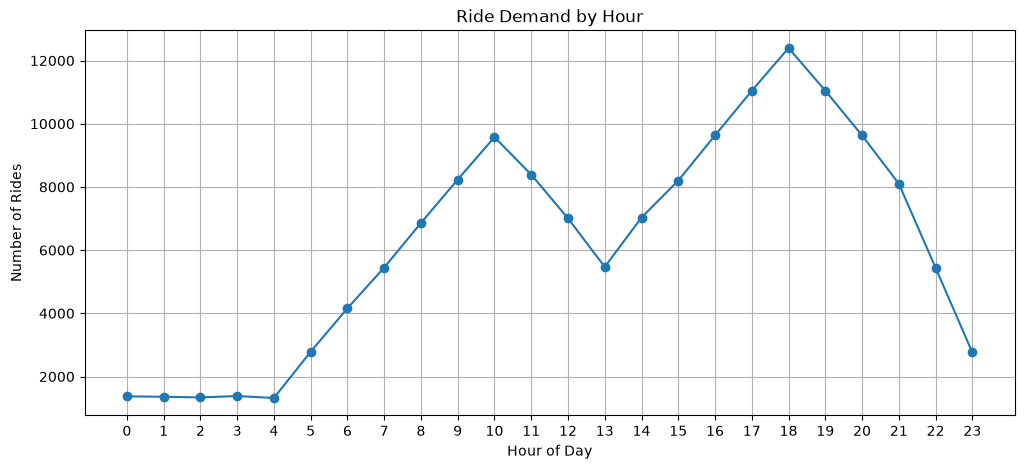

In [38]:
hourly_rides=rd['Hour'].value_counts().sort_index()#.reset_index(name='no_of_rides')
print(hourly_rides)
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_rides.index,#hourly_rides.Hour,
    hourly_rides.values,#hourly_rides.no_of_rides,
    marker="o"
)

plt.title("Ride Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")

plt.xticks(range(24))
plt.grid(True)

plt.show()


Day_of_Week
Monday       21644
Tuesday      21391
Wednesday    21413
Thursday     21215
Friday       21397
Saturday     21542
Sunday       21398
Name: count, dtype: int64


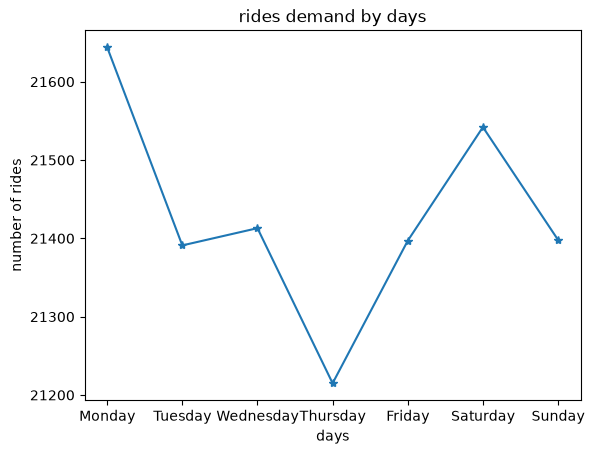

In [39]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
d_d=rd['Day_of_Week'].value_counts().reindex(day_order)
print(d_d)
plt.plot(d_d.index,d_d.values,marker='*')
plt.xlabel('days')
plt.ylabel('number of rides')
plt.title('rides demand by days')
plt.show()

Month
January      12861
February     11927
March        12719
April        12199
May          12778
June         12440
July         12897
August       12636
September    12248
October      12651
November     12394
December     12250
Name: count, dtype: int64


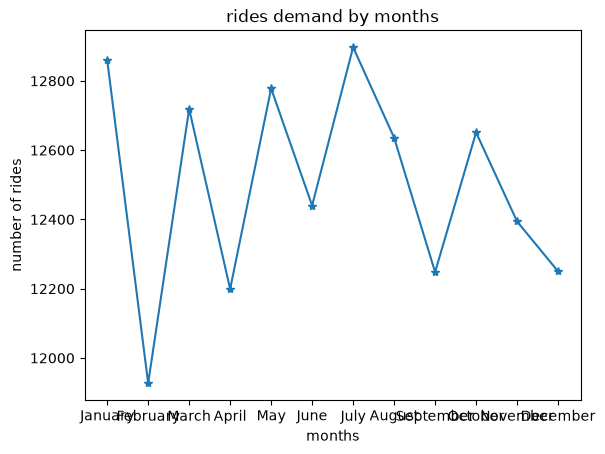

In [40]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
m_d=rd['Month'].value_counts().reindex(month_order)
print(m_d)
plt.plot(m_d.index,m_d.values,marker='*')
plt.xlabel('months')
plt.ylabel('number of rides')
plt.title('rides demand by months')
plt.show()

Pickup Location
Khandsa            949
Barakhamba Road    946
Saket              931
Badarpur           921
Pragati Maidan     920
Name: count, dtype: int64


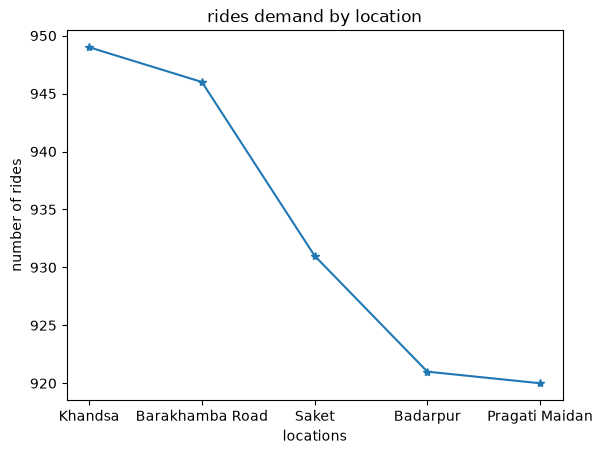

Drop Location
Ashram             936
Basai Dhankot      917
Lok Kalyan Marg    916
Narsinghpur        913
Cyber Hub          912
Name: count, dtype: int64


In [41]:
pickup_counts = rd["Pickup Location"].value_counts().sort_index().sort_values(ascending=False).head()
print(pickup_counts)
plt.plot(pickup_counts.index,pickup_counts.values,marker='*')
plt.xlabel('locations')
plt.ylabel('number of rides')
plt.title('rides demand by location')
plt.show()
drop_counts=rd['Drop Location'].value_counts().sort_values(ascending=False).head()
print(drop_counts)

In [42]:
rd['r_d']=rd["Pickup Location"]+"->"+rd["Drop Location"]
print(rd['r_d'])

0                       Palam Vihar->Jhilmil
1           Shastri Nagar->Gurgaon Sector 56
2                     Khandsa->Malviya Nagar
3              Central Secretariat->Inderlok
4              Ghitorni Village->Khan Market
                         ...                
149995                     MG Road->Ghitorni
149996          Golf Course Road->Akshardham
149997      Satguru Ram Singh Marg->Jor Bagh
149998                 Ghaziabad->Saidulajab
149999    Ashok Park Main->Gurgaon Sector 29
Name: r_d, Length: 150000, dtype: str


                            route  count
0         DLF City Court->Bhiwadi     17
1            Akshardham->RK Puram     16
2  Janakpuri->Faridabad Sector 15     16
3           Ghaziabad->Badshahpur     15
4           Jor Bagh->Rohini East     15


Text(0.5, 1.0, 'toatal routes')

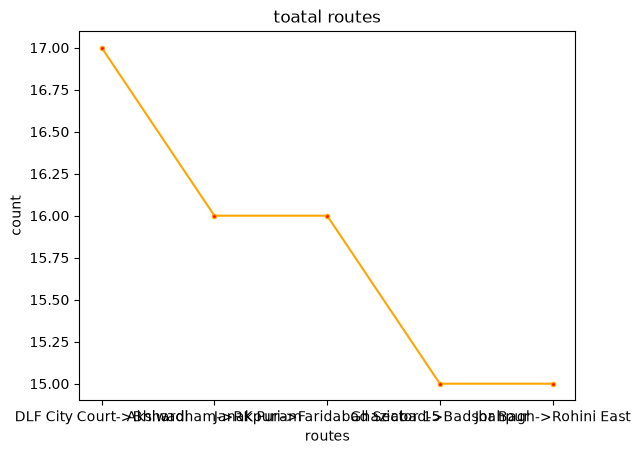

In [43]:
route_counts = rd["r_d"].value_counts().rename_axis("route").reset_index(name="count").sort_values(by='count',ascending=False).head()
print(route_counts)
plt.plot(route_counts['route'],route_counts['count'],marker='.',color='orange',mfc='red')
plt.xlabel('routes')
plt.ylabel('count')
plt.title('toatal routes')

In [44]:
t_r=0
l=0
for i in rd.index:
    if rd['Booking Status'][i]=='Completed':
        t_r+=rd['Booking Value'][i]
        l+=1
print(l)
print(t_r)

93000
47260574.0


In [45]:
completed_rides = rd[rd["Booking Status"].str.strip().str.lower() == "completed"].copy()
#print(completed_rides.reset_index(drop=True))
total_revenue = completed_rides["Booking Value"].sum()
avg_revenue=completed_rides["Booking Value"].mean()
total_dis=completed_rides['Ride Distance'].sum()
avg_dis=completed_rides["Ride Distance"].mean()
print("Total Revenue:", total_revenue)
print('Average Revenue:', avg_revenue)
print('toatal distance:', total_dis)
print('Average distance:',avg_dis)
#print(completed_rides.head())
print(completed_rides.columns)


Total Revenue: 47260574.0
Average Revenue: 508.17821505376344
toatal distance: 2418045.84
Average distance: 26.000492903225805
Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method', 'Hour',
       'Day_of_Week', 'Month', 'Month_Number', 'r_d'],
      dtype='str')


        Month  month rev
0     January  4001547.0
1    February  3756610.0
2       March  4174900.0
3       April  3885255.0
4         May  3935207.0
5        June  3964298.0
6        July  3961939.0
7      August  3867753.0
8   September  3820536.0
9     October  4008403.0
10   November  3938458.0
11   December  3945668.0


[Text(0, 3, '4001547'),
 Text(0, 3, '3756610'),
 Text(0, 3, '4174900'),
 Text(0, 3, '3885255'),
 Text(0, 3, '3935207'),
 Text(0, 3, '3964298'),
 Text(0, 3, '3961939'),
 Text(0, 3, '3867753'),
 Text(0, 3, '3820536'),
 Text(0, 3, '4008403'),
 Text(0, 3, '3938458'),
 Text(0, 3, '3945668')]

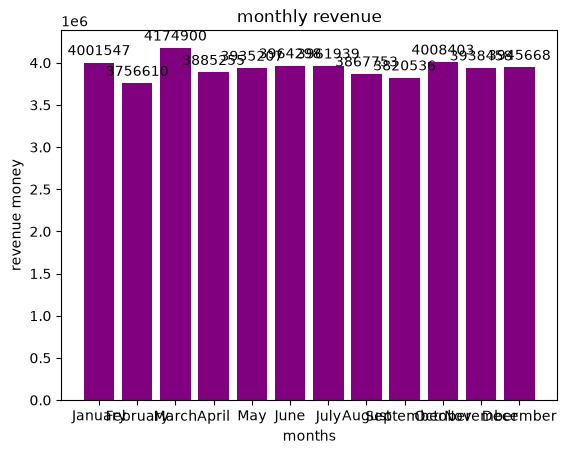

In [46]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_rev=completed_rides.groupby('Month')['Booking Value'].sum().reindex(month_order).reset_index(name='month rev')
print(monthly_rev)
bars=plt.bar(monthly_rev['Month'],monthly_rev['month rev'],color='purple')
plt.xlabel('months')
plt.ylabel('revenue money')
plt.title('monthly revenue')
plt.bar_label(bars, fmt="%.0f", padding=3)

In [47]:
v=rd.groupby('Pickup Location')['Vehicle Type'].value_counts()
cr=rd['Customer Rating'].value_counts()
print(v)
print(cr)

Pickup Location  Vehicle Type 
AIIMS            Auto             248
                 Go Mini          173
                 Go Sedan         152
                 Bike             151
                 Premier Sedan    111
                                 ... 
Yamuna Bank      Go Sedan         145
                 Bike             117
                 Premier Sedan    103
                 eBike             60
                 Uber XL           23
Name: count, Length: 1232, dtype: int64
Customer Rating
0.0    57000
4.9    11642
4.6    11533
4.3    10995
4.2    10697
4.5     5890
4.8     5880
5.0     5837
4.7     5763
4.1     5396
4.4     5279
3.9     2370
3.8     2357
3.7     2354
3.6     1194
4.0     1185
3.1     1008
3.4      928
3.3      900
3.2      881
3.0      468
3.5      443
Name: count, dtype: int64


In [48]:
dr= rd["Driver Ratings"].value_counts()
print(dr)

Driver Ratings
0.0    57000
4.3    14081
4.2    13841
4.6     9368
4.4     7018
4.1     6966
4.9     4705
4.7     4678
4.5     4634
3.9     3915
3.8     3848
3.7     3790
5.0     2365
4.8     2328
3.6     2026
4.0     1995
3.2     1538
3.4     1491
3.3     1461
3.1     1459
3.5      748
3.0      745
Name: count, dtype: int64


In [49]:
customer_data=completed_rides.groupby('Customer ID').agg(total_rides=('Booking ID','count'),total_spending=('Booking Value','sum'),avg_dis=('Ride Distance','mean'),customer_rating=('Customer Rating','mean')).reset_index()
print(customer_data.head())

    Customer ID  total_rides  total_spending  avg_dis  customer_rating
0  "CID1000234"            1           458.0    13.32              4.3
1  "CID1000323"            1          1498.0    20.26              4.5
2  "CID1000448"            1           448.0    12.93              4.2
3  "CID1000469"            1           419.0    36.14              4.3
4  "CID1000588"            1           253.0    37.10              4.1


In [50]:
features = ['total_rides','total_spending','avg_dis','customer_rating']
X = customer_data[features]
print(X.head())

   total_rides  total_spending  avg_dis  customer_rating
0            1           458.0    13.32              4.3
1            1          1498.0    20.26              4.5
2            1           448.0    12.93              4.2
3            1           419.0    36.14              4.3
4            1           253.0    37.10              4.1


In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#print(X_scaled[:5])

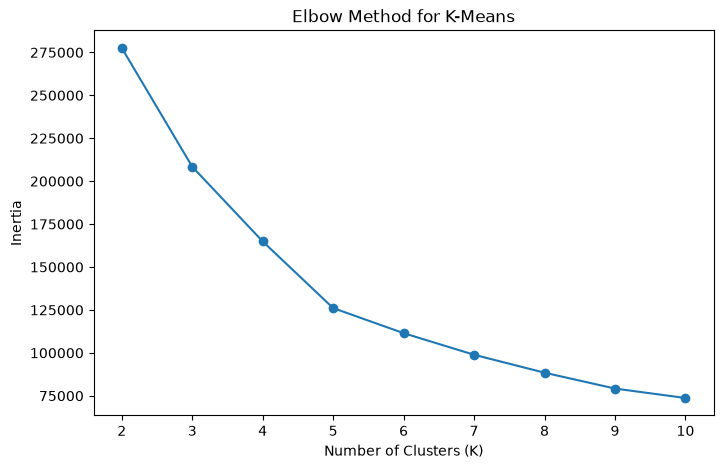

In [52]:
from sklearn.cluster import KMeans
inertia = []
for k in range(2, 11):
    kmeans = KMeans( n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11),inertia,marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.show()

In [71]:
n_clusters=4
kmeans = KMeans(n_clusters=n_clusters,random_state=42,n_init=10)
customer_data["Cluster"] = kmeans.fit_predict(X_scaled)
customer_data.head()
customer_data.to_csv(r"C:\Users\heman\OneDrive\Documents\customer_data.csv", index=False)

In [54]:
cluster_summary = customer_data.groupby("Cluster")[features].mean().round(2)
print(cluster_summary)

         total_rides  total_spending  avg_dis  customer_rating
Cluster                                                       
0               1.00          513.47    38.19             4.55
1               1.00          503.59    13.81             4.54
2               2.01          998.84    25.63             4.40
3               1.00          506.79    25.74             3.63


Cluster
0    39121
1    38820
2      450
3    14156
Name: count, dtype: int64


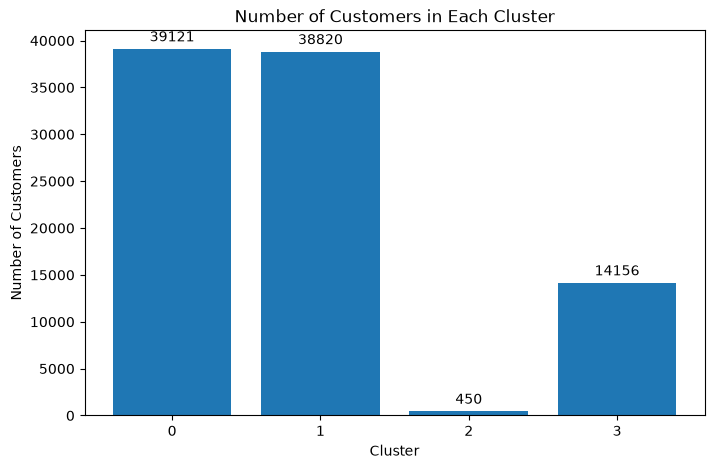

In [55]:
cluster_counts = customer_data["Cluster"].value_counts().sort_index()
plt.figure(figsize=(8, 5))
print(cluster_counts)
bars = plt.bar(cluster_counts.index.astype(str),cluster_counts.values)
plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.bar_label(bars, fmt="%.0f", padding=3)
plt.show()

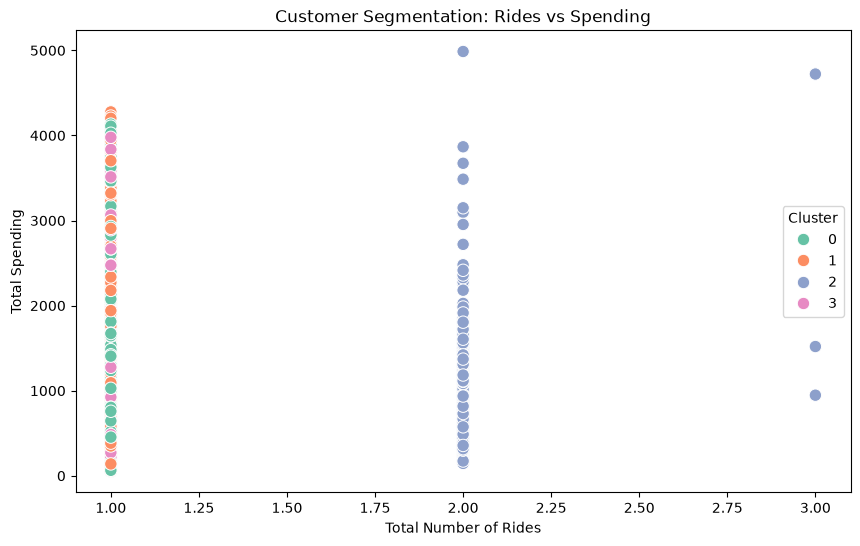

In [56]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_data,x="total_rides",y="total_spending",hue="Cluster",palette="Set2",s=80)
plt.title("Customer Segmentation: Rides vs Spending")
plt.xlabel("Total Number of Rides")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")
plt.show()

In [57]:
day_hr_d=pd.crosstab(rd['Month'],rd['Hour']).reindex(month_order)
#print(day_hr_d)
p_m=rd['Month'].value_counts().reindex(month_order).sort_values(ascending=False)
print(p_m)
p_h=rd['Hour'].value_counts().sort_values(ascending=False)
#print(p_h)
p_d=rd['Day_of_Week'].value_counts().reindex(day_order).sort_values(ascending=False)
print(p_d)

Month
July         12897
January      12861
May          12778
March        12719
October      12651
August       12636
June         12440
November     12394
December     12250
September    12248
April        12199
February     11927
Name: count, dtype: int64
Day_of_Week
Monday       21644
Saturday     21542
Wednesday    21413
Sunday       21398
Friday       21397
Tuesday      21391
Thursday     21215
Name: count, dtype: int64


In [58]:
pro_veh = completed_rides.groupby('Vehicle Type')['Booking Value'].sum().sort_values(ascending=False)
print(pro_veh)

Vehicle Type
Auto             11727615.0
Go Mini           9411418.0
Go Sedan          8538560.0
Bike              7144913.0
Premier Sedan     5733655.0
eBike             3298157.0
Uber XL           1406256.0
Name: Booking Value, dtype: float64


In [59]:
top_customers=customer_data.sort_values(by='total_spending',ascending=False).reset_index(drop=True).head(5)
print(top_customers)

    Customer ID  total_rides  total_spending  avg_dis  customer_rating  \
0  "CID2674107"            2          4987.0    31.83         3.650000   
1  "CID7828101"            3          4722.0    28.44         4.166667   
2  "CID2706299"            1          4277.0     8.66         4.900000   
3  "CID4843078"            1          4228.0    11.73         5.000000   
4  "CID2978596"            1          4220.0    10.11         4.800000   

   Cluster  
0        2  
1        2  
2        1  
3        1  
4        1  


In [60]:
booking_status=rd['Booking Status'].value_counts()
print(booking_status)

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


In [61]:
incomplete_rides=rd[rd["Booking Status"].str.lower()!='completed']
incomplete_rides.head()
#print(incomplete_rides['Booking Status'].value_counts())

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,Day_of_Week,Month,Month_Number,r_d
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,0.0,0.0,...,0.0,0.00,0.0,0.0,NaN,12,Saturday,March,3,Palam Vihar->Jhilmil
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,237.0,5.73,0.0,0.0,UPI,18,Friday,November,11,Shastri Nagar->Gurgaon Sector 56
8,2024-09-14,12:49:09,"""CNR4510807""",No Driver Found,"""CID7873618""",Go Sedan,Noida Sector 62,Noida Sector 18,0.0,0.0,...,0.0,0.00,0.0,0.0,NaN,12,Saturday,September,9,Noida Sector 62->Noida Sector 18
9,2024-12-16,19:06:48,"""CNR7721892""",Incomplete,"""CID5214275""",Auto,Rohini,Adarsh Nagar,6.1,26.0,...,135.0,10.36,0.0,0.0,Cash,19,Monday,December,12,Rohini->Adarsh Nagar
11,2024-09-18,08:09:38,"""CNR9551927""",No Driver Found,"""CID7568143""",Auto,Vidhan Sabha,AIIMS,0.0,0.0,...,0.0,0.00,0.0,0.0,NaN,8,Wednesday,September,9,Vidhan Sabha->AIIMS


In [62]:
print('Total Ride: ',len(rd))
print('Completed Rides: ',len(completed_rides))
print('Incomplete Rides: ',len(incomplete_rides))
print(incomplete_rides['Booking Status'].value_counts())
print('Total Revenue: ',round(total_revenue,2))
print('Average Revenue: ',round(avg_revenue,2))
print('Total distance: ',round(total_dis,2))
print('Average distance: ',round(avg_dis,2))
print('Peak Hours: ',p_h.head())
print('Peak day: ',p_d.head())
print('Peak Month: ',p_m.head())




Total Ride:  150000
Completed Rides:  93000
Incomplete Rides:  57000
Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64
Total Revenue:  47260574.0
Average Revenue:  508.18
Total distance:  2418045.84
Average distance:  26.0
Peak Hours:  Hour
18    12397
19    11047
17    11044
16     9633
20     9630
Name: count, dtype: int64
Peak day:  Day_of_Week
Monday       21644
Saturday     21542
Wednesday    21413
Sunday       21398
Friday       21397
Name: count, dtype: int64
Peak Month:  Month
July       12897
January    12861
May        12778
March      12719
October    12651
Name: count, dtype: int64


In [63]:
print("========== RIDE SHARING ANALYSIS SUMMARY ==========")

print("\n1. TOTAL BOOKINGS")
print("Total bookings:", len(rd))

print("\n2. COMPLETED RIDES")
print("Completed rides:", len(completed_rides))

print("\n3. REVENUE")
print("Total revenue:", round(total_revenue, 2))
print("Average revenue:", round(avg_revenue, 2))

print("\n4. DISTANCE")
print("Total distance:", round(total_dis, 2))
print("Average distance:", round(avg_dis, 2))

print("\n5. PEAK HOURS")
print(p_h.head(5))

print("\n6. TOP PICKUP LOCATIONS")
print(pickup_counts.head(5))

print("\n7. TOP DROP LOCATIONS")
print(drop_counts.head(5))

print("\n8. TOP ROUTES")
print(route_counts.head(5))

print("\n9. PAYMENT METHODS")
print(payment_methods.head(5))

print("\n10. VEHICLE TYPES")
print(vehicle_count)

print("\n11. BOOKING STATUS")
print(booking_status)

print("\n12. CUSTOMER CLUSTERS")
print(cluster_summary.head(5))

print("\n13. TOP CUSTOMERS")
print(top_customers[
    ["Customer ID", "total_rides", "total_spending"]
])

========== RIDE SHARING ANALYSIS SUMMARY ==========

1. TOTAL BOOKINGS
Total bookings: 150000

2. COMPLETED RIDES
Completed rides: 93000

3. REVENUE
Total revenue: 47260574.0
Average revenue: 508.18

4. DISTANCE
Total distance: 2418045.84
Average distance: 26.0

5. PEAK HOURS
Hour
18    12397
19    11047
17    11044
16     9633
20     9630
Name: count, dtype: int64

6. TOP PICKUP LOCATIONS
Pickup Location
Khandsa            949
Barakhamba Road    946
Saket              931
Badarpur           921
Pragati Maidan     920
Name: count, dtype: int64

7. TOP DROP LOCATIONS
Drop Location
Ashram             936
Basai Dhankot      917
Lok Kalyan Marg    916
Narsinghpur        913
Cyber Hub          912
Name: count, dtype: int64

8. TOP ROUTES
                            route  count
0         DLF City Court->Bhiwadi     17
1            Akshardham->RK Puram     16
2  Janakpuri->Faridabad Sector 15     16
3           Ghaziabad->Badshahpur     15
4           Jor Bagh->Rohini East     15

9. PAYMENT

In [64]:
rd.to_csv(r"C:\Users\heman\OneDrive\Documents\rd.csv", index=False)

In [65]:
rd.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,Day_of_Week,Month,Month_Number,r_d
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,0.0,0.0,...,0.0,0.00,0.0,0.0,NaN,12,Saturday,March,3,Palam Vihar->Jhilmil
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,237.0,5.73,0.0,0.0,UPI,18,Friday,November,11,Shastri Nagar->Gurgaon Sector 56
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,627.0,13.58,4.9,4.9,Debit Card,8,Friday,August,8,Khandsa->Malviya Nagar
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,416.0,34.02,4.6,5.0,UPI,17,Monday,October,10,Central Secretariat->Inderlok
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,737.0,48.21,4.1,4.3,UPI,22,Monday,September,9,Ghitorni Village->Khan Market


In [66]:
completed_rides.to_csv(r"C:\Users\heman\OneDrive\Documents\completed_rides.csv", index=False)

In [67]:
m_r=completed_rides.groupby('Month')['Booking Value'].sum()
print(m_r)

Month
April        3885255.0
August       3867753.0
December     3945668.0
February     3756610.0
January      4001547.0
July         3961939.0
June         3964298.0
March        4174900.0
May          3935207.0
November     3938458.0
October      4008403.0
September    3820536.0
Name: Booking Value, dtype: float64


In [68]:
t_r=completed_rides.groupby('Day_of_Week')['Booking ID'].count()
print(t_r)

Day_of_Week
Friday       13253
Monday       13318
Saturday     13442
Sunday       13314
Thursday     13206
Tuesday      13171
Wednesday    13296
Name: Booking ID, dtype: int64


In [69]:
v_r=completed_rides.groupby('Customer Rating')['Booking ID'].count()
print(v_r)

Customer Rating
3.0      468
3.1     1008
3.2      881
3.3      900
3.4      928
3.5      443
3.6     1194
3.7     2354
3.8     2357
3.9     2370
4.0     1185
4.1     5396
4.2    10697
4.3    10995
4.4     5279
4.5     5890
4.6    11533
4.7     5763
4.8     5880
4.9    11642
5.0     5837
Name: Booking ID, dtype: int64


In [70]:
cluster_summary.head()

,total_rides,total_spending,avg_dis,customer_rating
Cluster,,,,
0,1.00,513.47,38.19,4.55
1,1.00,503.59,13.81,4.54
2,2.01,998.84,25.63,4.40
3,1.00,506.79,25.74,3.63
